# 第 1 课：声音与采样（从零开始）

这一课只回答四个问题：声音是什么？波形是什么？采样率是什么？16 kHz 到底意味着什么？

学习方法：每个小节都按 **概念 → 代码 → 先猜后验证的题目** 进行。不要追求一次记住所有公式，先建立图像和单位的直觉。

预备知识只需要会：变量、乘法、函数调用，以及看懂横轴和纵轴。

<!-- course-upgrade-v2 -->
## 学习导航

| 项目 | 内容 |
|---|---|
| 所属阶段 | 声音与声学特征 |
| 建议投入 | 2～4 小时，可分 2～3 次完成 |
| 前置要求 | 无；只需要会运行 Notebook |
| 本课核心 | 采样率、幅值与归一化、dBFS与参考值 |
| 完成标准 | 能口头解释核心概念；独立完成强化题；从空白重写核心函数 |

高效顺序：**先回答前测 → 预测代码结果 → 再运行 → 修改一个变量 → 关闭答案复现 → 次日回忆。**


<!-- course-upgrade-v2 -->
## 课前诊断（先不要运行代码）

1. 分别用一句话解释：采样率、幅值与归一化、dBFS与参考值。
2. 画出这三个概念之间的输入—输出关系。
3. 写下你最不确定的一点，并给出一个暂时猜测。

自评：答对 0～1 题先复习前置课；答对 2 题可以正常学习；3 题都能讲清楚则直接挑战代码和迁移题。


## 1. 声音是什么？

声音是空气压力随时间变化的现象。麦克风把压力变化转换成电信号，计算机再把电信号记录成数字。

我们用一个函数表示连续声音：

$$x(t)$$

横轴是时间，纵轴是瞬时振幅。振幅大通常意味着声音更响，变化快通常意味着频率更高。

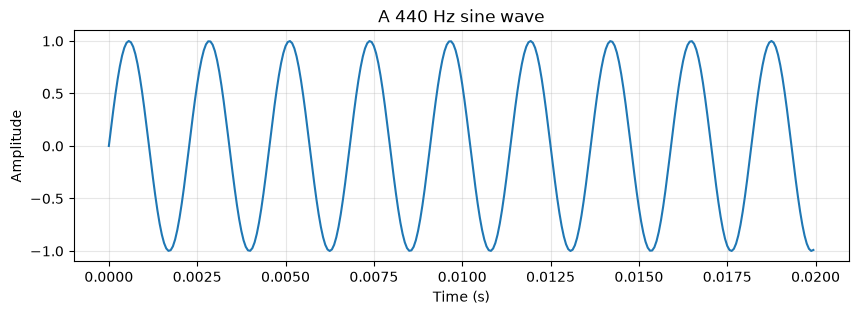

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 生成一个 440 Hz 的纯音：不是读取文件，而是先用数学制造声音
sr = 16_000
duration = 0.02
t = np.arange(int(sr * duration)) / sr
x = np.sin(2 * np.pi * 440 * t)

plt.figure(figsize=(10, 3))
plt.plot(t, x)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('A 440 Hz sine wave')
plt.grid(alpha=0.3)
plt.show()

### 练习 1

1. 把 `440` 改成 `880`，波形的周期会变长还是变短？
2. 把振幅乘以 `0.3`，波形的高度发生什么变化？
3. 这张图的横轴总共显示多少秒？

## 2. 采样率是什么？

计算机不能记录无限连续的 $x(t)$，只能每隔固定时间测一次：

$$x[0], x[1], x[2], \ldots$$

采样率 $f_s$ 表示每秒测量多少次。16 kHz 就是每秒 16,000 个采样点。

采样间隔为 $1/16000=62.5$ 微秒。根据奈奎斯特定理，16 kHz 理论上最多表示 8 kHz 的频率。

In [2]:
sr = 16_000
print('每秒采样点数:', sr)
print('采样间隔（微秒）:', 1e6 / sr)
print('理论最高频率（Hz）:', sr / 2)

# 1 秒音频有多少个采样点？
one_second = np.zeros(sr)
print('数组长度:', len(one_second))

每秒采样点数: 16000
采样间隔（微秒）: 62.5
理论最高频率（Hz）: 8000.0
数组长度: 16000


### 练习 2

1. 8 kHz 的理论最高频率是多少？
2. 1 秒的 16 kHz 音频有多少个采样点？
3. 2.5 秒的 16 kHz 音频有多少个采样点？请先手算，再运行代码验证。

## 3. 采样会发生什么？

下面把连续的正弦曲线和离散采样点画在一起。蓝线只是便于观察的连续曲线，橙点才是计算机真正保存的数据。

G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 36830 (\N{CJK UNIFIED IDEOGRAPH-8FDE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 32493 (\N{CJK UNIFIED IDEOGRAPH-7EED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 37319 (\N{CJK UNIFIED IDEOGRAPH-91C7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

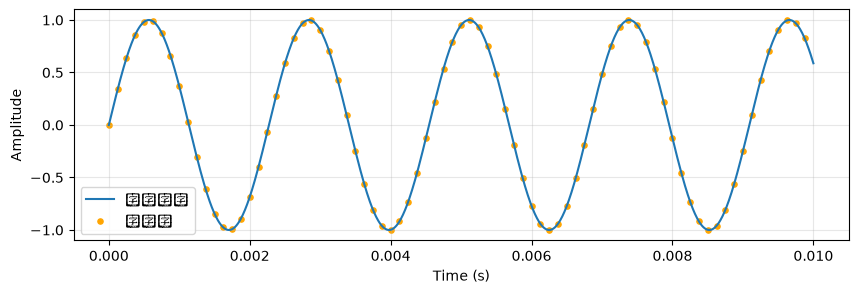

In [3]:
frequency = 440
sr = 8_000
duration = 0.01
t = np.arange(int(sr * duration)) / sr
x = np.sin(2 * np.pi * frequency * t)

t_dense = np.linspace(0, duration, 1000)
x_dense = np.sin(2 * np.pi * frequency * t_dense)
plt.figure(figsize=(10, 3))
plt.plot(t_dense, x_dense, label='连续曲线')
plt.scatter(t, x, s=14, color='orange', label='采样点')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(alpha=0.3)
plt.show()

### 练习 3：判断题

不看答案，先写下你的判断：

1. 采样率越高，代表每个采样点的振幅一定越大。
2. 采样率为 16 kHz 时，20 kHz 的纯音可以被准确记录。
3. 波形的纵轴主要表示振幅，而不是频率。

答案：1 错，采样率只决定时间采样密度；2 错，16 kHz 的奈奎斯特频率是 8 kHz；3 对。

## 4. 振幅、频率、周期：三个容易混淆的量

对 $x(t)=A\sin(2\pi ft)$：

- $A$ 是振幅：波形上下有多高，主要对应强弱。
- $f$ 是频率：每秒振荡多少次，单位 Hz。
- $T$ 是周期：完成一次振荡需要多久，$T=1/f$。

例如 440 Hz 的周期是 $1/440\approx2.27$ ms。频率加倍，周期减半；振幅加倍，周期不变。

C:\Users\zjj\AppData\Local\Temp\ipykernel_17740\3466436958.py:10: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjj\AppData\Local\Temp\ipykernel_17740\3466436958.py:10: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjj\AppData\Local\Temp\ipykernel_17740\3466436958.py:10: UserWarning: Glyph 25913 (\N{CJK UNIFIED IDEOGRAPH-6539}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjj\AppData\Local\Temp\ipykernel_17740\3466436958.py:10: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjj\AppData\Local\Temp\ipykernel_17740\3466436958.py:10: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjj\AppData\Local\Temp\ipykernel_17740\3466436958.py:10: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENT

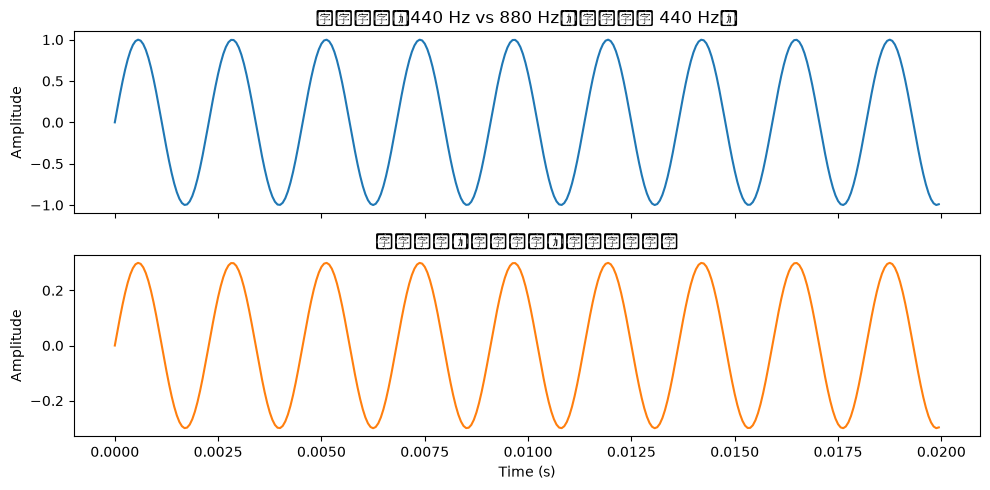

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
t = np.arange(320) / 16_000
axes[0].plot(t, np.sin(2*np.pi*440*t))
axes[0].set_title('频率改变：440 Hz vs 880 Hz（这里只画 440 Hz）')
axes[0].set_ylabel('Amplitude')
axes[1].plot(t, 0.3*np.sin(2*np.pi*440*t), color='tab:orange')
axes[1].set_title('振幅变小：频率不变，波形高度变小')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

### 练习 4

1. 880 Hz 的周期约是多少毫秒？
2. 如果把 $0.3\sin(2\pi\cdot440t)$ 改为 $0.6\sin(2\pi\cdot440t)$，频率会变吗？
3. 一个声音振幅很大但频率很低，你会把它描述为‘响但低沉’还是‘轻但尖’？为什么？

参考答案：1 约 1.14 ms；2 不变；3 响但低沉。

## 5. 奈奎斯特频率与混叠（aliasing）

采样率为 $f_s$ 时，能可靠表示的最高频率是 $f_s/2$。如果输入频率超过这个值，采样后会伪装成另一个较低频率，这叫混叠。

这不是‘信息变少一点’，而是不同的连续声音可能产生完全相同的采样点。因此录音设备通常在采样前使用低通抗混叠滤波器。

C:\Users\zjj\AppData\Local\Temp\ipykernel_17740\1856505400.py:14: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


C:\Users\zjj\AppData\Local\Temp\ipykernel_17740\1856505400.py:14: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjj\AppData\Local\Temp\ipykernel_17740\1856505400.py:14: UserWarning: Glyph 20110 (\N{CJK UNIFIED IDEOGRAPH-4E8E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjj\AppData\Local\Temp\ipykernel_17740\1856505400.py:14: UserWarning: Glyph 22856 (\N{CJK UNIFIED IDEOGRAPH-5948}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjj\AppData\Local\Temp\ipykernel_17740\1856505400.py:14: UserWarning: Glyph 22862 (\N{CJK UNIFIED IDEOGRAPH-594E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjj\AppData\Local\Temp\ipykernel_17740\1856505400.py:14: UserWarning: Glyph 26031 (\N{CJK UNIFIED IDEOGRAPH-65AF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjj\AppData\Local\Temp\ipykernel_17740\1856505400.py:14: UserWarning: Glyph 29305 (\N{CJK UNIFIE

G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 36229 (\N{CJK UNIFIED IDEOGRAPH-8D85}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20250 (\N{CJK UNIFIED IDEOGRAPH-4F1A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21457 (\N{CJK UNIFIED IDEOGRAPH-53D1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

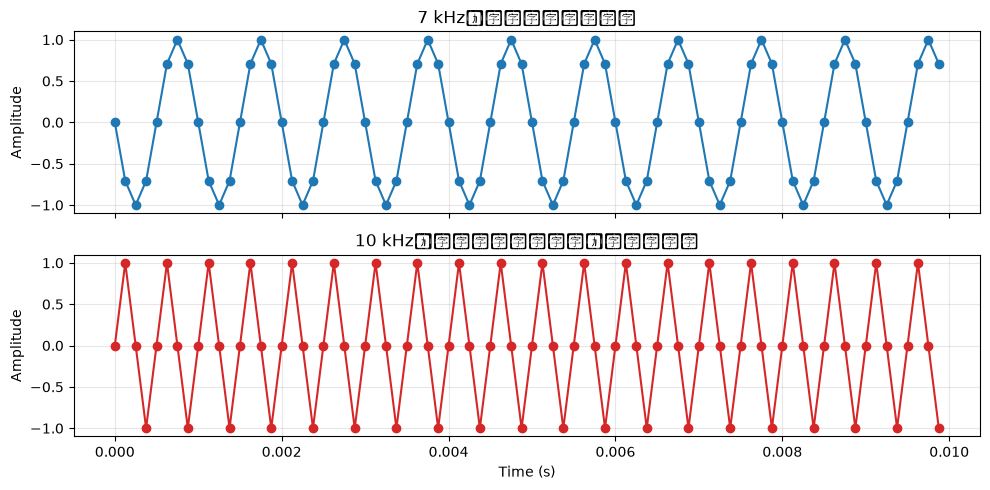

In [5]:
sr = 8_000
duration = 0.01
t = np.arange(int(sr*duration)) / sr
# 7 kHz 小于 8 kHz，10 kHz 大于 8 kHz
x1 = np.sin(2*np.pi*7_000*t)
x2 = np.sin(2*np.pi*10_000*t)
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t[:80], x1[:80], 'o-')
axes[0].set_title('7 kHz：低于奈奎斯特频率')
axes[1].plot(t[:80], x2[:80], 'o-', color='tab:red')
axes[1].set_title('10 kHz：超过奈奎斯特频率，会发生混叠')
axes[1].set_xlabel('Time (s)')
for ax in axes: ax.set_ylabel('Amplitude'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 练习 5：计算题

1. 采样率 16 kHz 时，最高可靠频率是多少？
2. 采样率 44.1 kHz 时，最高可靠频率是多少？
3. 为什么语音识别常见 16 kHz，而音乐常见 44.1 kHz 或 48 kHz？

提示：想想它们需要保留的最高频率和数据量。

答案：1 为 8 kHz；2 为 22.05 kHz；3 音乐需要更宽的听觉频带，语音则可以用较低采样率节省数据。

## 6. 交互实验：拖动滑块观察波形

如果你在 Jupyter 中运行下面的单元格，会出现两个滑块。拖动频率时，观察周期数量变化；拖动振幅时，观察高度变化。

In [6]:
import ipywidgets as widgets
from IPython.display import display

def draw_sine(frequency=440, amplitude=1.0):
    t = np.linspace(0, 0.02, 1000)
    y = amplitude * np.sin(2*np.pi*frequency*t)
    plt.figure(figsize=(10, 3))
    plt.plot(t, y)
    plt.title(f'frequency={frequency} Hz, amplitude={amplitude:.1f}')
    plt.xlabel('Time (s)'); plt.ylabel('Amplitude')
    plt.grid(alpha=0.3); plt.show()

widgets.interact(
    draw_sine,
    frequency=widgets.IntSlider(value=440, min=100, max=2000, step=20, description='频率'),
    amplitude=widgets.FloatSlider(value=1.0, min=0.1, max=1.0, step=0.1, description='振幅'),
)

interactive(children=(IntSlider(value=440, description='频率', max=2000, min=100, step=20), FloatSlider(value=1.…

<function __main__.draw_sine(frequency=440, amplitude=1.0)>

### 交互题 A

1. 固定振幅，把频率从 200 Hz 拖到 1000 Hz，图中单位时间内的周期数如何变化？
2. 固定频率，把振幅从 1.0 拖到 0.2，周期是否变化？
3. 你能否用‘上下高度’和‘横向密度’分别解释振幅和频率？

## 7. 交互实验：采样率与采样点

橙色点是计算机真正保存的采样值，蓝线只是连续信号的参考。降低采样率时，点会变稀。

In [7]:
def draw_sampling(sample_rate=8000, frequency=440):
    duration = 0.01
    t_dense = np.linspace(0, duration, 1000)
    y_dense = np.sin(2*np.pi*frequency*t_dense)
    t = np.arange(int(sample_rate*duration)) / sample_rate
    y = np.sin(2*np.pi*frequency*t)
    plt.figure(figsize=(10, 3))
    plt.plot(t_dense, y_dense, label='连续信号')
    plt.scatter(t, y, color='orange', s=18, label=f'采样点 ({sample_rate} Hz)')
    plt.xlabel('Time (s)'); plt.ylabel('Amplitude')
    plt.title(f'采样率={sample_rate} Hz, 信号频率={frequency} Hz, Nyquist={sample_rate/2:.0f} Hz')
    plt.legend(); plt.grid(alpha=0.3); plt.show()

widgets.interact(
    draw_sampling,
    sample_rate=widgets.IntSlider(value=8000, min=1000, max=16000, step=1000, description='采样率'),
    frequency=widgets.IntSlider(value=440, min=100, max=10000, step=100, description='信号频率'),
)

interactive(children=(IntSlider(value=8000, description='采样率', max=16000, min=1000, step=1000), IntSlider(valu…

<function __main__.draw_sampling(sample_rate=8000, frequency=440)>

### 交互题 B

1. 把采样率设为 8000 Hz，把信号频率设为 3000 Hz，观察点是否足够密？
2. 保持采样率 8000 Hz，把信号频率设为 7000 Hz，再设为 9000 Hz。两种情况下采样点看起来有什么异常？
3. 计算 8000 Hz 采样率的奈奎斯特频率，并解释为什么 9000 Hz 会有混叠风险。

## 本课小结

| 概念 | 一句话 | 单位/公式 |
|---|---|---|
| 波形 | 振幅随时间变化 | $x(t)$ |
| 振幅 | 上下有多高，主要对应强弱 | 无量纲或归一化值 |
| 频率 | 每秒振荡多少次 | Hz |
| 周期 | 一次振荡需要多久 | $T=1/f$ |
| 采样率 | 每秒记录多少个采样点 | Hz |
| 奈奎斯特频率 | 可可靠表示的最高频率 | $f_s/2$ |

自测：如果你能用自己的话解释‘16 kHz = 每秒 16,000 次测量，最高可靠频率约 8 kHz’，就可以进入下一课。

下一课：从波形切出 frame，加入 window，使用 hop 产生 STFT 的时间轴。

<!-- course-upgrade-v2 -->
## 强化练习：第 1 课专属题库

请先把答案写进新的 Markdown/Code cell，再展开自评标准。

### A. 基础回忆

1. 不看上文，分别定义 `采样率`、`幅值与归一化`、`dBFS与参考值`。
2. 哪一个量/状态是本课最容易在模块边界丢失的？它的单位和 shape 是什么？
3. 本课至少写出两个“看起来能运行，但结果其实错误”的例子。

### B. 预测与推理

4. 场景：**把 8 kHz 文件误标为 16 kHz 播放**。先预测现象，再说明原因，最后给出一项可以验证猜测的指标。
5. 改变本课最关键参数的 0.5×、1×、2×，分别预测准确率、延迟、内存或数值误差怎样变化。
6. 画一张最小数据流图，在每条边标出 dtype、shape、时间单位或概率/代价方向。

### C. 编程与排错

7. 编程任务：**生成 440 Hz 正弦波并验证周期、峰值、RMS 和 dBFS**。至少加入正常、边界、错误输入三类测试。
8. 故意制造一个 off-by-one、shape、状态未 reset 或数值稳定性错误；记录错误现象和定位过程。
9. 不看本课实现，从空白 cell 重写最核心函数，并用原实现作数值对照。

### D. 迁移与表达

10. 跨课任务：**解释本课量怎样进入第 2 课分帧**。
11. 用 90 秒向没有学过 ASR 的人解释本课；禁止只念术语，必须举一个数字或生活例子。
12. 写出一个生产系统中会监控的指标，以及它异常时优先检查的三处位置。

<details><summary>展开自评标准</summary>

- 每题 0～2 分：0=无法回答；1=方向正确但缺少单位、边界或验证；2=解释完整且能用代码/数字验证。
- 24 分满分：达到 19 分再进入下一课；15～18 分次日重做错题；低于 15 分回看本课图和核心代码。
- 第 4 题必须包含“预测—原因—指标”，第 7～9 题必须真正运行测试，第 10 题必须明确上下游 contract。
- 核心答案至少应正确使用：采样率、幅值与归一化、dBFS与参考值。

</details>


<!-- course-upgrade-v2 -->
## 间隔复习与离场票

### 离场票（现在完成）

- [ ] 我能不用笔记解释 采样率、幅值与归一化、dBFS与参考值。
- [ ] 我能说出本课最常见的错误及其观测现象。
- [ ] 我能从空白重写一个核心函数，并通过至少 3 个测试。
- [ ] 我能说明本课对上一层和下一层接口的影响。

### 复习时间表

- **明天（5 分钟）**：闭卷写出三个核心概念和一个公式/shape。
- **7 天后（15 分钟）**：重做第 4、7、10 题，不运行原答案。
- **30 天后（20 分钟）**：从真实音频或随机张量重新构造一个最小实验。

把错题记录到根目录 `LEARNING_LOG.md`。不要只写“不会”，要写：原判断、证据、正确规则、下次检查动作。
